明白，直接给你一个简洁的速查表。

| 组件 | 作用 | 简单例子 |
| :--- | :--- | :--- |
| **`ggplot()`** | 初始化画布，指定数据 | `ggplot(df)` |
| **`aes()`** | 定义映射：哪列是X，哪列是Y，颜色等 | `aes(x='年龄', y='身高', color='性别')` |
| **`geom_xxx()`** | 决定图形类型（点、线、柱等） | `geom_point()` (散点图)<br>`geom_line()` (折线图)<br>`geom_bar()` (柱状图) |
| **`scale_xxx()`** | 调整坐标轴或颜色映射的刻度/范围 | `scale_x_log10()` (X轴变对数)<br>`scale_color_manual()` (手动设颜色) |
| **`labs()`** | 修改标题、坐标轴和图例的文字 | `labs(title='标题', x='X轴名')` |
| **`theme()`** | 调整非数据的样式（背景、网格、字体） | `theme_bw()` (黑白主题)<br>`theme(legend_position='left')` (图例放左边) |
| **`facet_xxx()`** | 分面，按某个变量生成多个子图 | `facet_wrap('~ 城市')` |

### 核心公式（记住这个就行）
```python
ggplot(数据, aes(x, y)) +   # 数据+映射
   geom_图形类型() +          # 图形
   其他调整()                 # 标签、主题、分面...
```

1. 直接从`ggplot()`方法开始，并且可以接受`pandas和polars`的作为输入参数(数据源)，


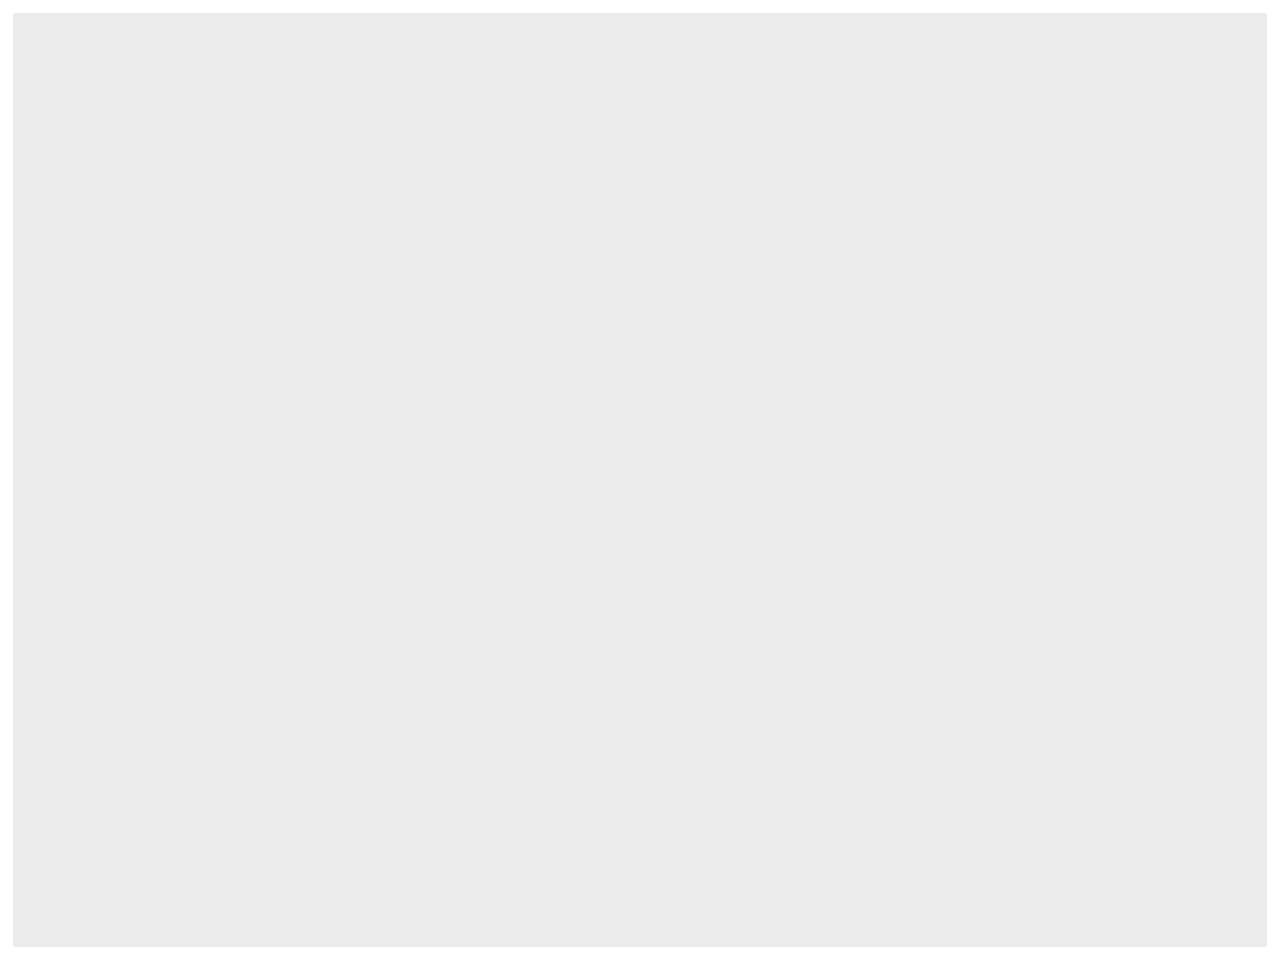

In [1]:
from plotnine import *
from plotnine.data import mpg

ggplot(data=mpg)

2. `aes`函数将数据映射到图形属性，比如说颜色，形状或者x, y轴坐标，(`aes`是`aesthetic`的缩写)

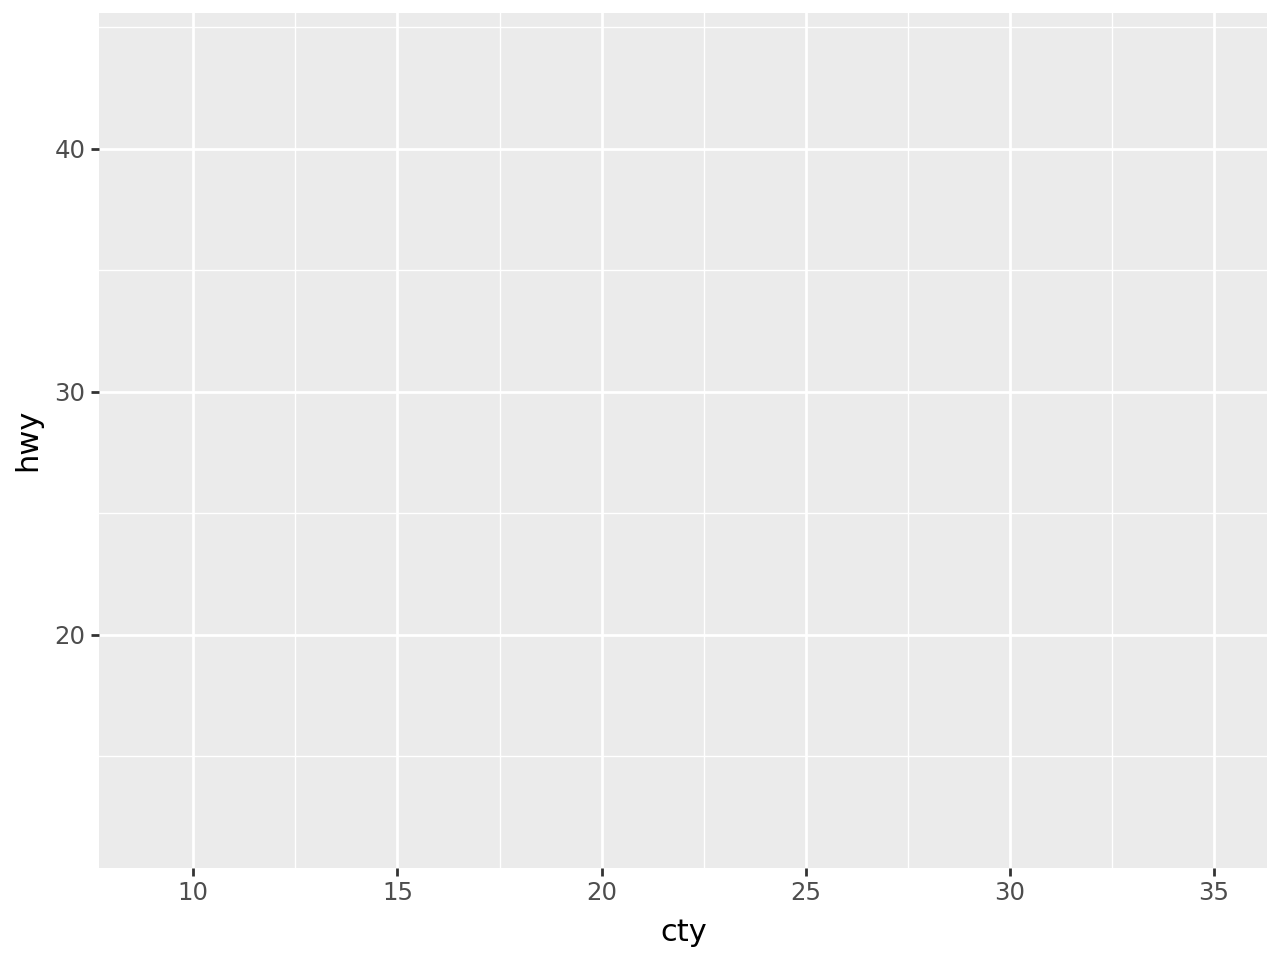

In [4]:
ggplot(data=mpg, mapping=aes(x="cty", y="hwy"))

3. 以 `geom_*()` 开头的函数用于指定要添加到绘图中的几何对象（geom）。几何对象决定了如何将映射数据转换为可视化元素，例如点、线，甚至是箱线图。

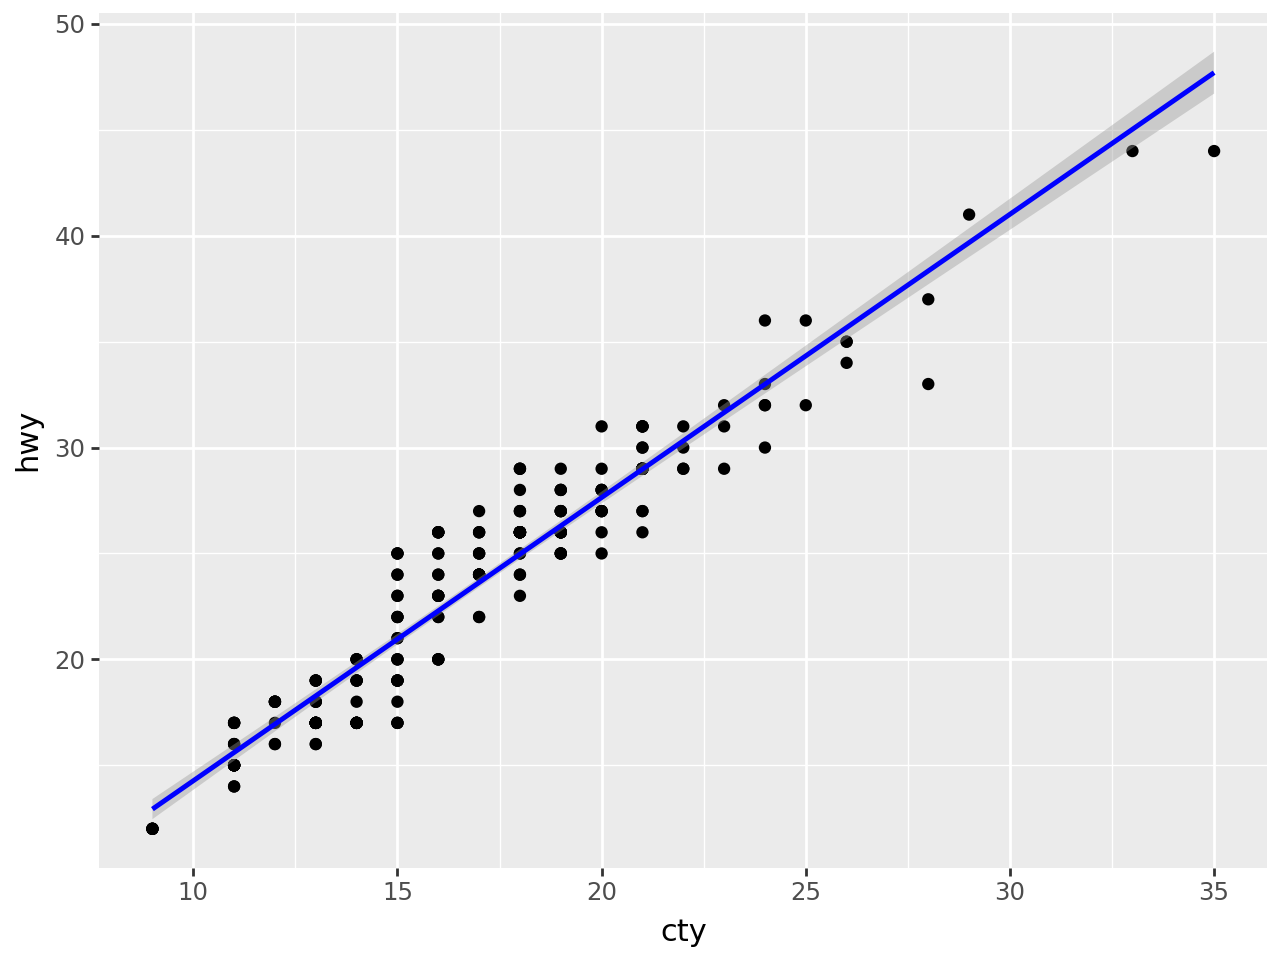

In [8]:
(
    ggplot(mpg, aes("cty", "hwy"))
    # to create a scatterplot 创建散点图
    + geom_point()
    # to fit and overlay a loess trendline 拟合并叠加黄土散度趋势线
    + geom_smooth(method="lm", color="blue")
)

4. `scale_*()` 函数用于自定义数据映射中视觉元素的样式。这包括调色板、坐标轴间距（例如对数刻度）、坐标轴范围等等。刻度可以设置坐标轴、图例和颜色条等参考线的名称。

刻度的名称遵循 `scale_<aesthetic>_<type>` 的格式，其中 `<aesthetic>` 是美学属性的名称，例如 x、y 或颜色。如果我们想使用 Plasma 调色板来设置颜色，可以使用以下代码：

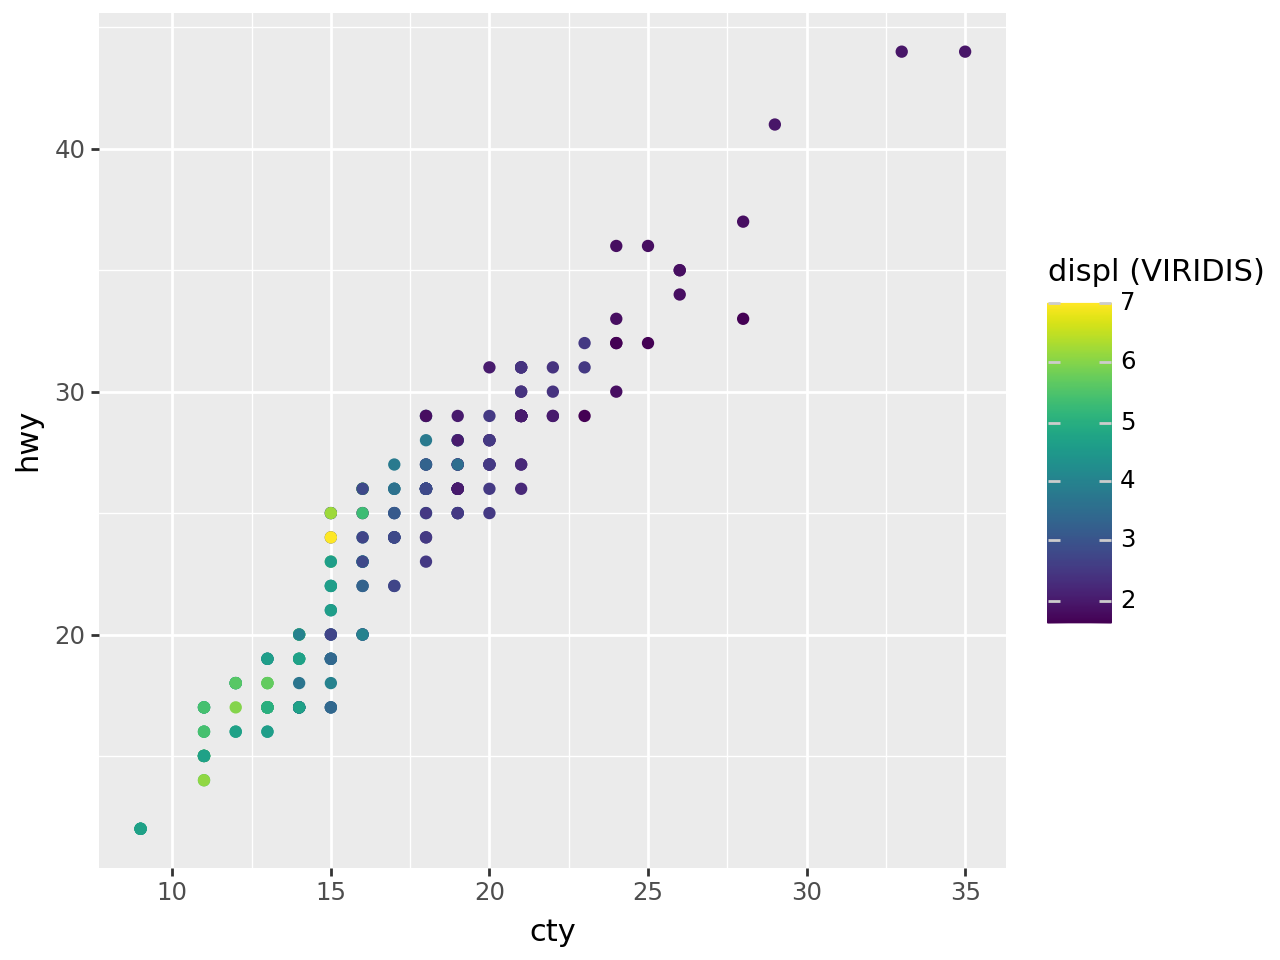

In [7]:
(
    ggplot(mpg, aes("cty", "hwy", color="displ"))
    + geom_point()
    + scale_color_continuous(name="displ (VIRIDIS)", cmap_name="viridis")
)

5. position_*() 函数用于调整图中元素的位置。例如，通过向点的 x 和 y 坐标添加少量随机噪声（抖动），使它们不会相互遮挡。

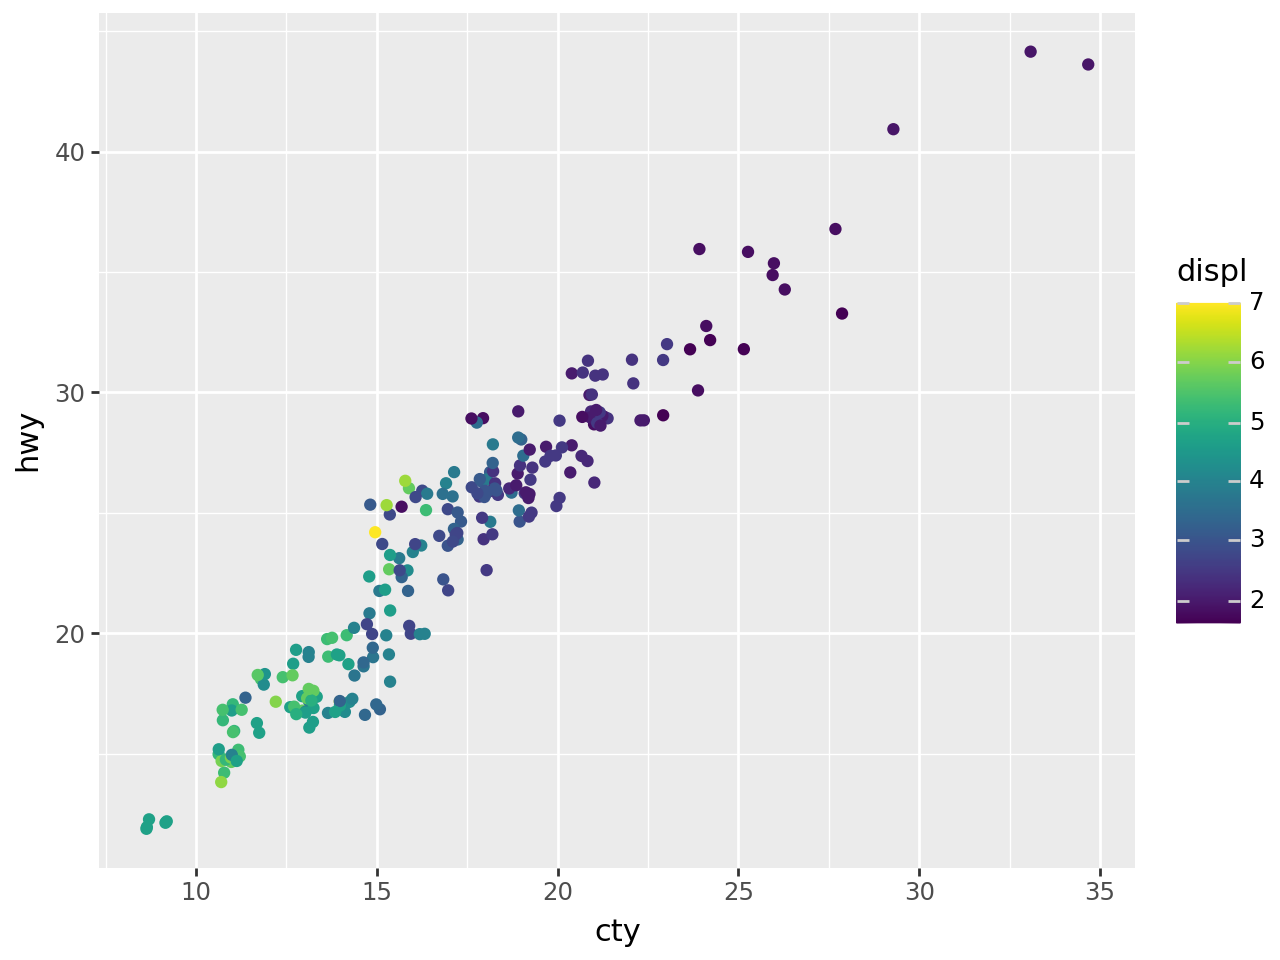

In [9]:
(
    ggplot(mpg, aes("cty", "hwy", color="displ"))
    # add a small amount of jitter
    + geom_point(position=position_jitter())
)

6. 分面功能可以将一个图表分割成多个子图。分面函数 facet_grid() 和 facet_wrap() 决定了如何分割数据。例如，我们可以根据 year 和 drv 列创建一个图表网格：

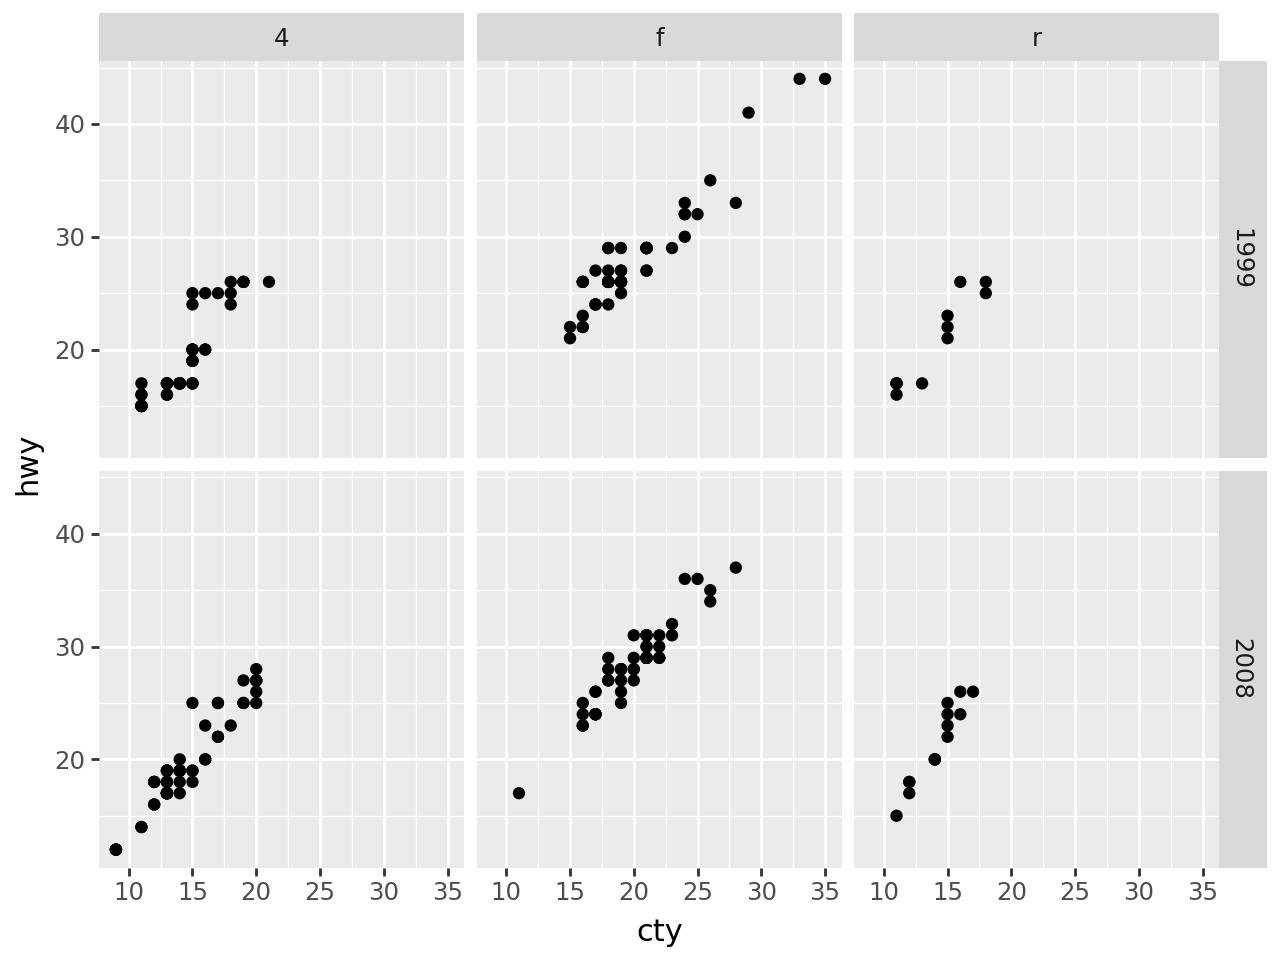

In [10]:
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point()
    # facet into subplots
    + facet_grid("year ~ drv")
)

7. `coord_*()` 函数用于指定绘图的坐标系。目前，仅支持少数几种坐标系。不过，未来将支持像 `coord_polar()` 这样的函数，从而可以使用极坐标进行绘图。

以下代码使用 `coord_fixed()` 函数来确保 x 轴和 y 轴的间距相同。

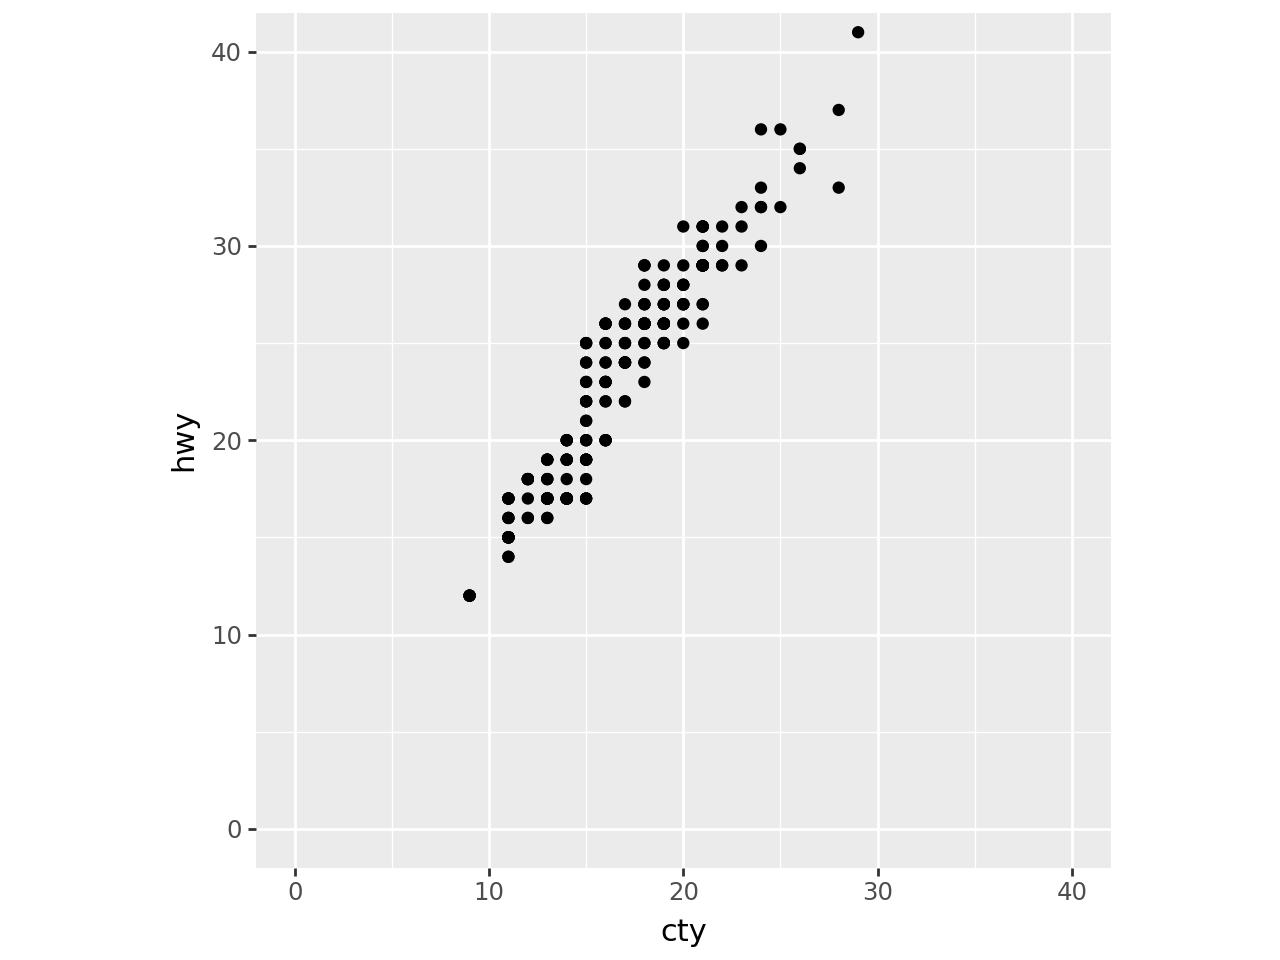

In [11]:
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point()
    + coord_fixed(xlim=[0, 40], ylim=[0, 40])
)

8. 主题控制图表中除数据本身之外的所有样式，包括图例位置、坐标轴颜色、文本大小等等。

使用 `theme_*()` 函数可以从预设主题入手，或使用 `theme()` 函数创建新的自定义主题。使用 `element_*()` 函数配置新的主题设置。

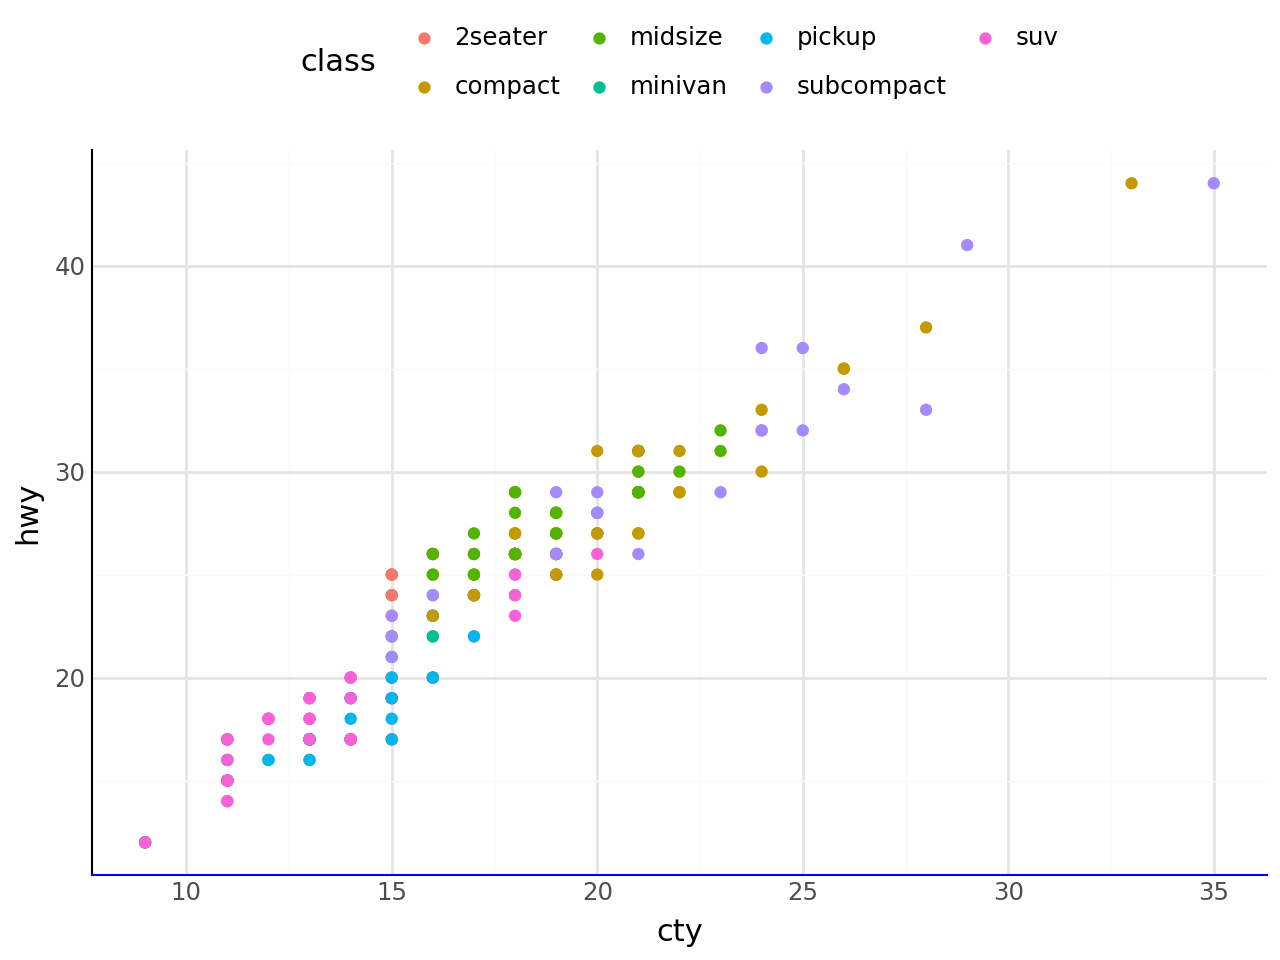

In [13]:
(
    ggplot(mpg, aes("cty", "hwy", colour="class"))
    + geom_point()
    + theme_minimal()
    + theme(
        legend_position="top",
        axis_line=element_line(linewidth=0.75),
        axis_line_x=element_line(colour="blue"),
    )
)

最后的叠加效果: 

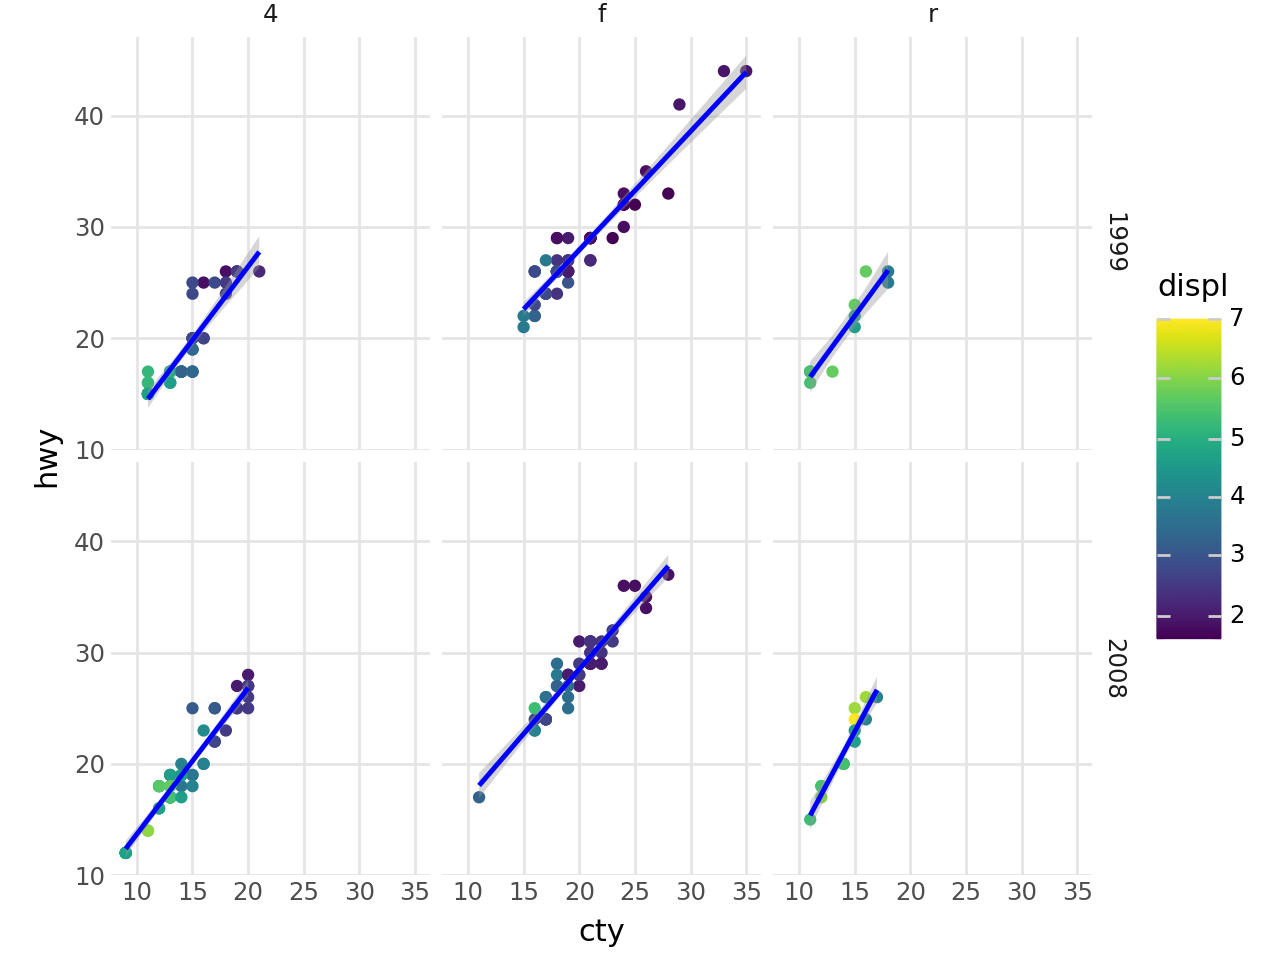

In [14]:
(
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point(mapping=aes(colour="displ"))
    + geom_smooth(method="lm", color="blue")
    + scale_color_continuous(cmap_name="viridis")
    + facet_grid("year ~ drv")
    + coord_fixed()
    + theme_minimal()
    + theme(panel_grid_minor=element_blank())
)